# Experiment: Grid-aligned Fgen comparison

Compare the existing native-grid Fgen calculation with nearest-neighbor and source-area-binned alignment on the shared regular latitude/longitude grid.

Success criteria:
- all methods return the standard Fgen evaluation columns;
- aligned methods preserve the main density-profile shape and component balance;
- differences from the original method are quantified rather than judged only from plots.


## Generate comparison data

Run this from the repository root before evaluating the notebook:

```bash
python scripts/GridAlignment/comparason_test.py \
  --models E3SM-1-0 MIROC6 ICON-ESM-LR \
  --methods original nearest binned \
  --last-n-months 12 \
  --output /glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen.pkl
```

The driver computes nonlinear diagnostics on the native grid first. Only the completed diagnostics are regridded for the aligned methods.


In [11]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_PATH = Path('/glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen.pkl')
RHO_PLOT_MIN = 1020.0
METHOD_STYLES = {
    'original': {'color': 'black', 'linestyle': '-', 'linewidth': 2.2},
    'nearest': {'color': 'tab:orange', 'linestyle': '--', 'linewidth': 1.8},
    'binned': {'color': 'tab:blue', 'linestyle': '-.', 'linewidth': 1.8},
}

if not RESULT_PATH.exists():
    raise FileNotFoundError(f'Run comparason_test.py first; missing {RESULT_PATH}')


In [12]:
with RESULT_PATH.open('rb') as handle:
    payload = pickle.load(handle)

metadata = payload['metadata']
results = payload['results']
methods = [method for method in ('original', 'nearest', 'binned') if method in results]
model_sets = [set(results[method]) for method in methods]
common_models = sorted(set.intersection(*model_sets)) if model_sets else []
errors = pd.DataFrame(payload.get('errors', []))
timings = pd.DataFrame(payload.get('timings', []))

print('Result file:', RESULT_PATH)
print('Common completed models:', common_models)
display(pd.Series(metadata, name='value').to_frame())
display(errors if not errors.empty else pd.DataFrame({'status': ['No recorded errors']}))


Result file: /glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen.pkl
Common completed models: ['ACCESS-CM2', 'CanESM5', 'E3SM-1-0', 'GISS-E2-2-G', 'ICON-ESM-LR', 'MIROC6', 'NorESM2-LM']


,value
created_utc,2026-06-07T08:44:40.519152+00:00
scenario,PIControl
models_requested,"[ACCESS-CM2, CanESM5, FGOALS-f3-L, GISS-E2-2-G..."
methods_requested,"[original, nearest, binned]"
resolution_degrees,2.0
last_n_years,2
last_n_months,12
rho_min,1015.0
rho_max,1030.0
step_size,0.05


,model,method,stage,error
0,FGOALS-f3-L,nearest,method,ValueError('Area latitude/longitude do not mat...
1,FGOALS-f3-L,binned,method,ValueError('Area latitude/longitude do not mat...


## Fgen density profiles

This follows the existing evaluation style: Fgen is plotted against density class, with the grid methods overlaid on the original result for each model.


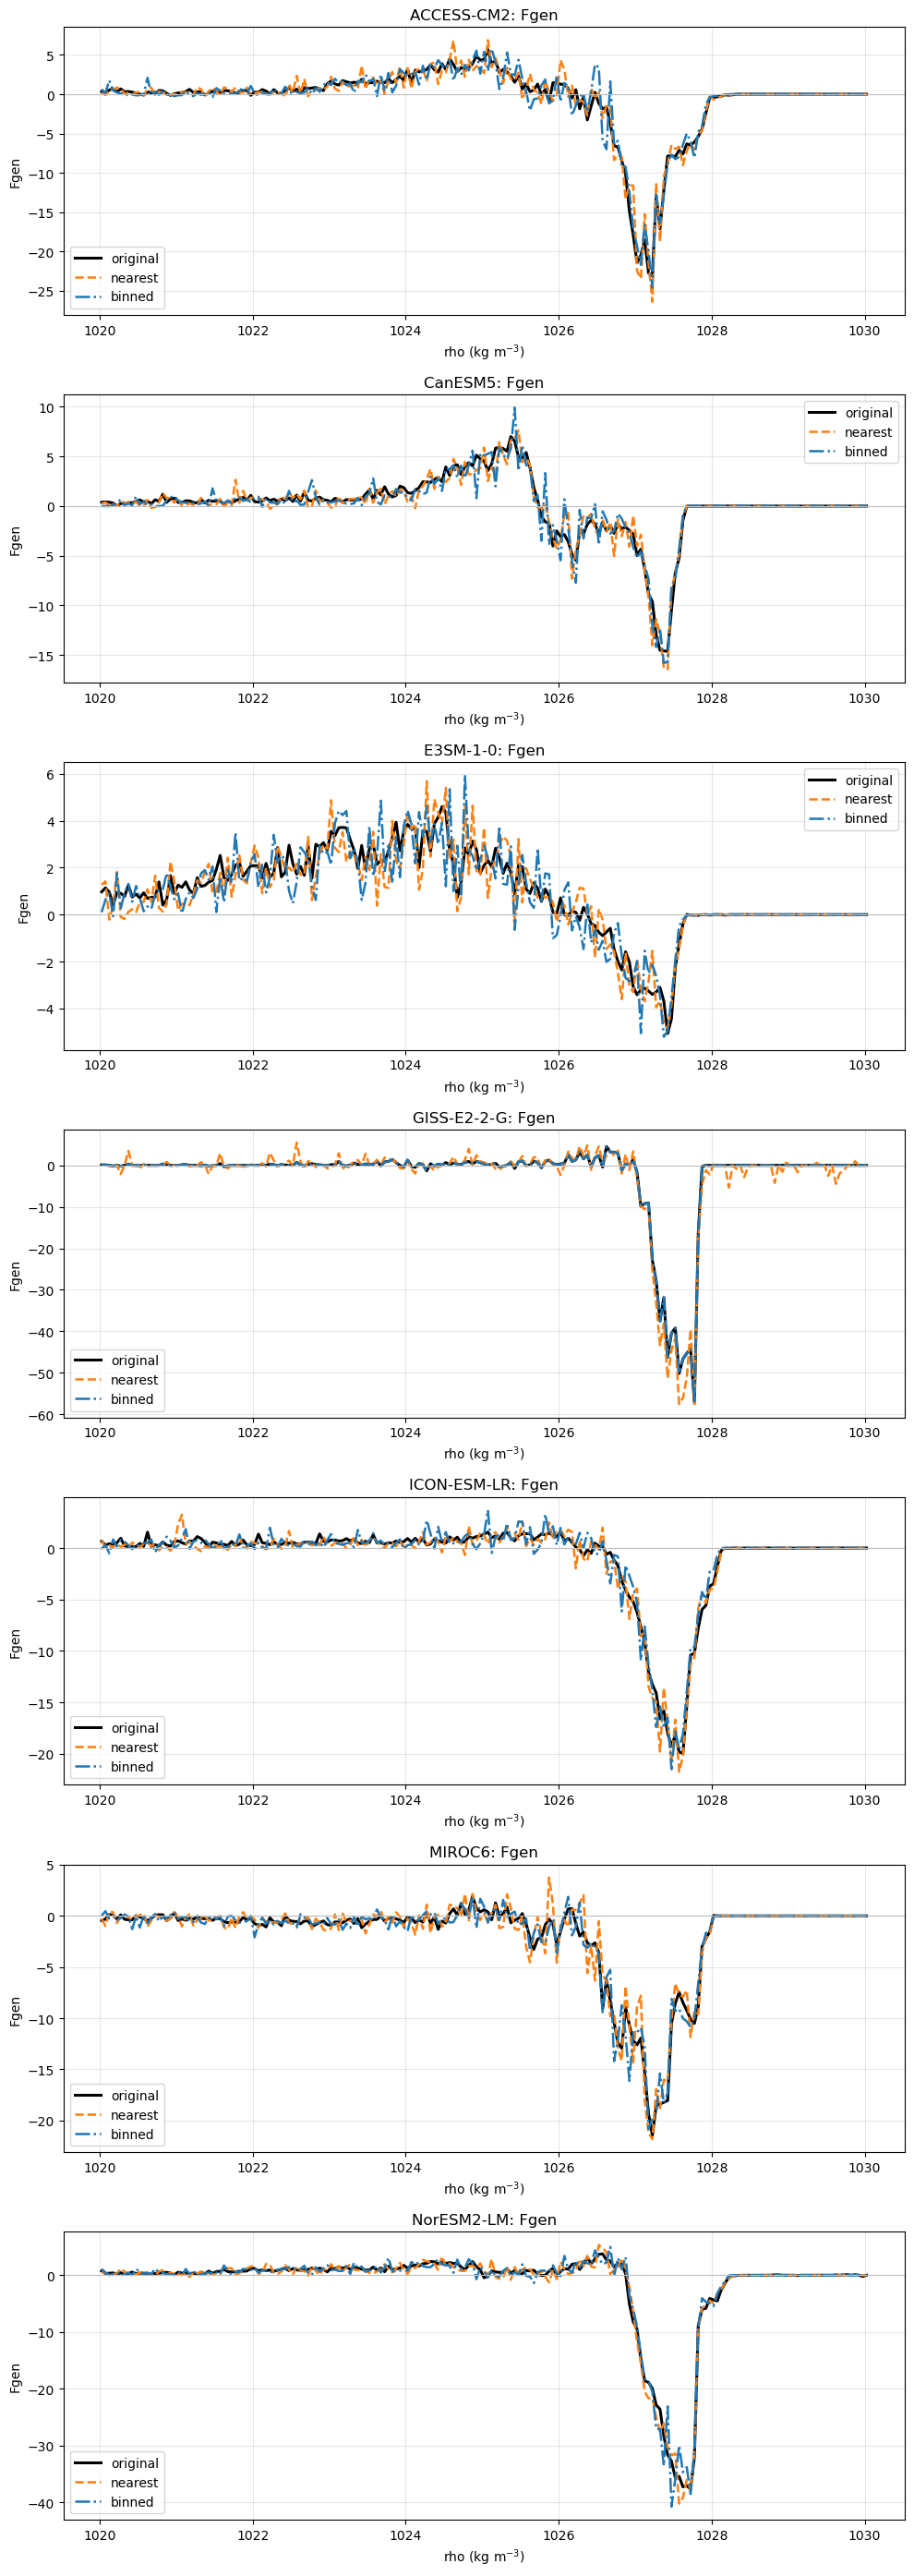

In [13]:
def plot_method_profiles(column, ylabel=None):
    if not common_models:
        raise ValueError('No models completed for every requested method')
    fig, axes = plt.subplots(len(common_models), 1, figsize=(10, 4 * len(common_models)), squeeze=False)
    for axis, model in zip(axes.ravel(), common_models):
        for method in methods:
            profile = results[method][model]
            profile = profile[profile['rho'] >= RHO_PLOT_MIN]
            axis.plot(profile['rho'], profile[column], label=method, **METHOD_STYLES[method])
        axis.axhline(0, color='0.75', linewidth=0.8)
        axis.set_title(f'{model}: {column}')
        axis.set_xlabel('rho (kg m$^{-3}$)')
        axis.set_ylabel(ylabel or column)
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()
    return fig

plot_method_profiles('Fgen', 'Fgen')
plt.show()


## Heat and freshwater components

Inspect whether a changed Fgen profile comes primarily from the heat-flux or freshwater-flux component.


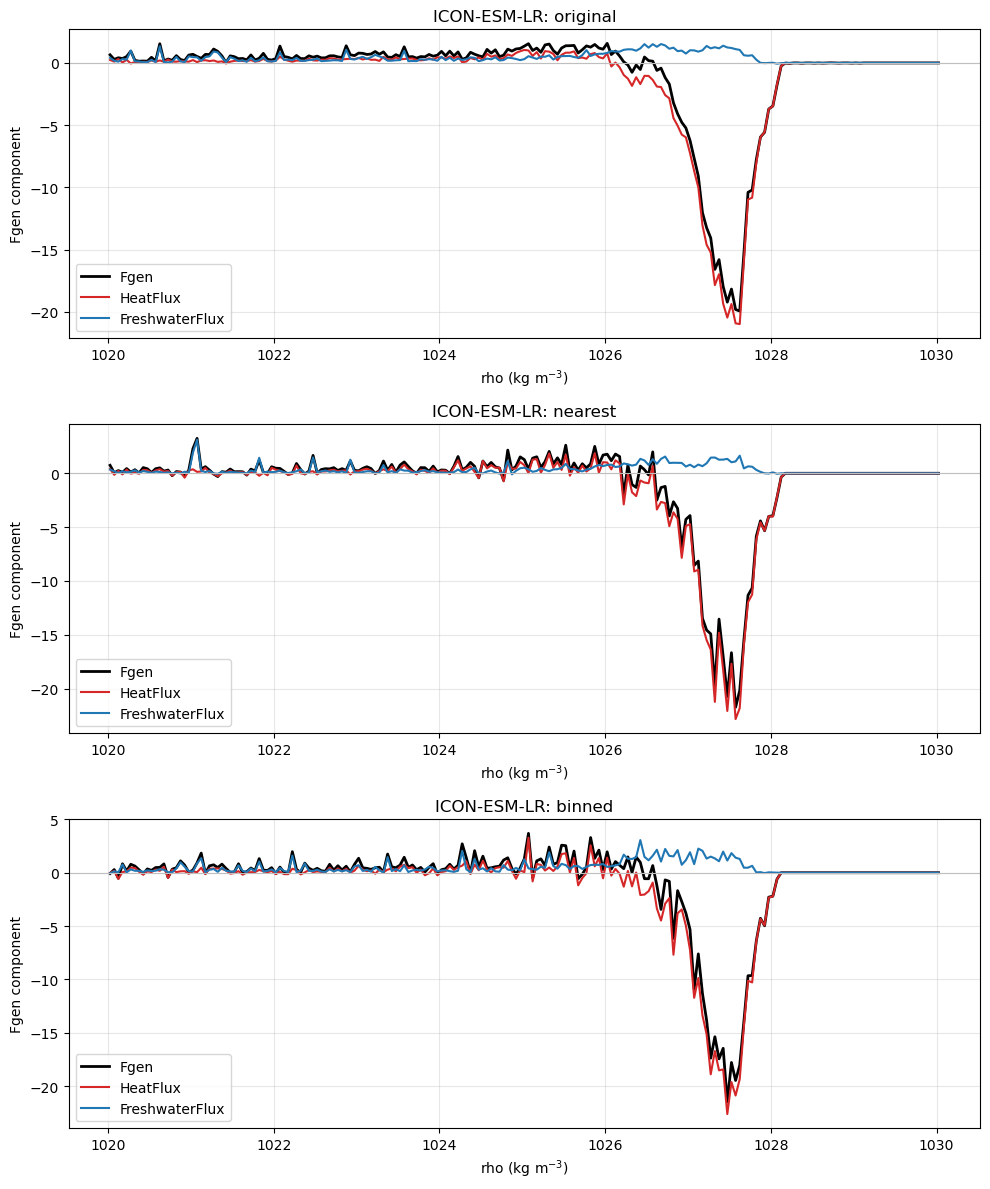

In [20]:
SELECTED_MODEL = common_models[4]

fig, axes = plt.subplots(len(methods), 1, figsize=(10, 4 * len(methods)), squeeze=False)
for axis, method in zip(axes.ravel(), methods):
    profile = results[method][SELECTED_MODEL]
    profile = profile[profile['rho'] >= RHO_PLOT_MIN]
    axis.plot(profile['rho'], profile['Fgen'], color='black', linewidth=2, label='Fgen')
    axis.plot(profile['rho'], profile['HeatFlux'], color='tab:red', label='HeatFlux')
    axis.plot(profile['rho'], profile['FreshwaterFlux'], color='tab:blue', label='FreshwaterFlux')
    axis.axhline(0, color='0.75', linewidth=0.8)
    axis.set_title(f'{SELECTED_MODEL}: {method}')
    axis.set_xlabel('rho (kg m$^{-3}$)')
    axis.set_ylabel('Fgen component')
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()


## Evaluation metrics

The summary uses the same types of metrics as the active Fgen evaluation notebooks: minimum values and the density integral of negative values. `AreaSum_total` is the sum of mean area across density bins.


In [15]:
def negative_integral(profile, column):
    negative_magnitude = np.clip(-profile[column].to_numpy(), 0.0, None)
    return float(np.trapz(negative_magnitude, profile['rho'].to_numpy()))

def profile_summary(model, method, profile):
    minimum_index = profile['Fgen'].idxmin()
    return {
        'model': model,
        'method': method,
        'Fgen_min': float(profile.loc[minimum_index, 'Fgen']),
        'rho_at_Fgen_min': float(profile.loc[minimum_index, 'rho']),
        'negative_Fgen_integral': negative_integral(profile, 'Fgen'),
        'negative_HeatFlux_integral': negative_integral(profile, 'HeatFlux'),
        'negative_FreshwaterFlux_integral': negative_integral(profile, 'FreshwaterFlux'),
        'AreaSum_total': float(profile['AreaSum'].sum()),
    }

summary = pd.DataFrame([
    profile_summary(model, method, results[method][model])
    for model in common_models
    for method in methods
])
summary.sort_values(['model', 'method'])


,model,method,Fgen_min,rho_at_Fgen_min,negative_Fgen_integral,negative_HeatFlux_integral,negative_FreshwaterFlux_integral,AreaSum_total
2,ACCESS-CM2,binned,-24.590369,1027.225,15.190328,19.250836,0.145905,1.415913e+13
1,ACCESS-CM2,nearest,-26.386733,1027.225,15.087256,18.808419,0.268643,1.414998e+13
0,ACCESS-CM2,original,-23.072229,1027.225,15.096655,19.232652,0.111473,1.459829e+13
5,CanESM5,binned,-15.810090,1027.375,8.794696,12.198496,0.000090,1.531117e+13
4,CanESM5,nearest,-16.441313,1027.425,8.752306,12.242278,0.001761,1.530518e+13
3,CanESM5,original,-14.624613,1027.425,8.948981,12.291263,0.000044,1.582918e+13
8,E3SM-1-0,binned,-5.204674,1027.375,3.093637,8.188939,0.169595,1.491838e+13
7,E3SM-1-0,nearest,-4.879666,1027.425,3.156090,8.123199,0.331424,1.493448e+13
6,E3SM-1-0,original,-5.061549,1027.425,2.842897,8.308956,0.060850,1.543019e+13
11,GISS-E2-2-G,binned,-57.229937,1027.775,27.301491,22.619143,5.109776,1.699932e+13


In [16]:
def percent_difference(value, reference):
    return np.nan if reference == 0 else 100.0 * (value - reference) / abs(reference)

comparison_rows = []
for model in common_models:
    reference_profile = results['original'][model].set_index('rho')
    reference_summary = summary[(summary['model'] == model) & (summary['method'] == 'original')].iloc[0]
    for method in methods:
        if method == 'original':
            continue
        aligned_profile = results[method][model].set_index('rho')
        joined = reference_profile[['Fgen']].join(aligned_profile[['Fgen']], lsuffix='_original', rsuffix='_aligned').dropna()
        method_summary = summary[(summary['model'] == model) & (summary['method'] == method)].iloc[0]
        difference = joined['Fgen_aligned'] - joined['Fgen_original']
        comparison_rows.append({
            'model': model,
            'method': method,
            'Fgen_RMSE': float(np.sqrt(np.mean(difference**2))),
            'Fgen_max_abs_difference': float(np.max(np.abs(difference))),
            'Fgen_min_percent_difference': percent_difference(method_summary['Fgen_min'], reference_summary['Fgen_min']),
            'negative_Fgen_integral_percent_difference': percent_difference(method_summary['negative_Fgen_integral'], reference_summary['negative_Fgen_integral']),
            'AreaSum_total_percent_difference': percent_difference(method_summary['AreaSum_total'], reference_summary['AreaSum_total']),
        })

comparison = pd.DataFrame(comparison_rows)
comparison.sort_values(['model', 'method'])


,model,method,Fgen_RMSE,Fgen_max_abs_difference,Fgen_min_percent_difference,negative_Fgen_integral_percent_difference,AreaSum_total_percent_difference
1,ACCESS-CM2,binned,9.678503e-01,5.363802e+00,-6.579947,0.620489,-3.008315
0,ACCESS-CM2,nearest,8.905496e-01,6.317299e+00,-14.365775,-0.062256,-3.070960
3,CanESM5,binned,8.495485e-01,4.914344e+00,-8.106043,-1.724047,-3.272496
2,CanESM5,nearest,7.066517e-01,4.419457e+00,-12.422214,-2.197732,-3.310379
5,E3SM-1-0,binned,7.715411e-01,3.145243e+00,-2.827684,8.819880,-3.316912
4,E3SM-1-0,nearest,6.172719e-01,2.131164e+00,3.593436,11.016688,-3.212598
7,GISS-E2-2-G,binned,6.616151e-17,1.110223e-15,0.000000,0.000000,0.000000
6,GISS-E2-2-G,nearest,1.512137e+00,9.460501e+00,-0.618841,22.120466,43.585363
9,ICON-ESM-LR,binned,7.758099e-01,3.316318e+00,-7.742632,-2.112949,-3.378150
8,ICON-ESM-LR,nearest,8.141038e-01,4.477896e+00,-8.947725,5.033988,-3.430202


## Difference from original

Direct profile differences show where density classes are shifted or smoothed by grid alignment.


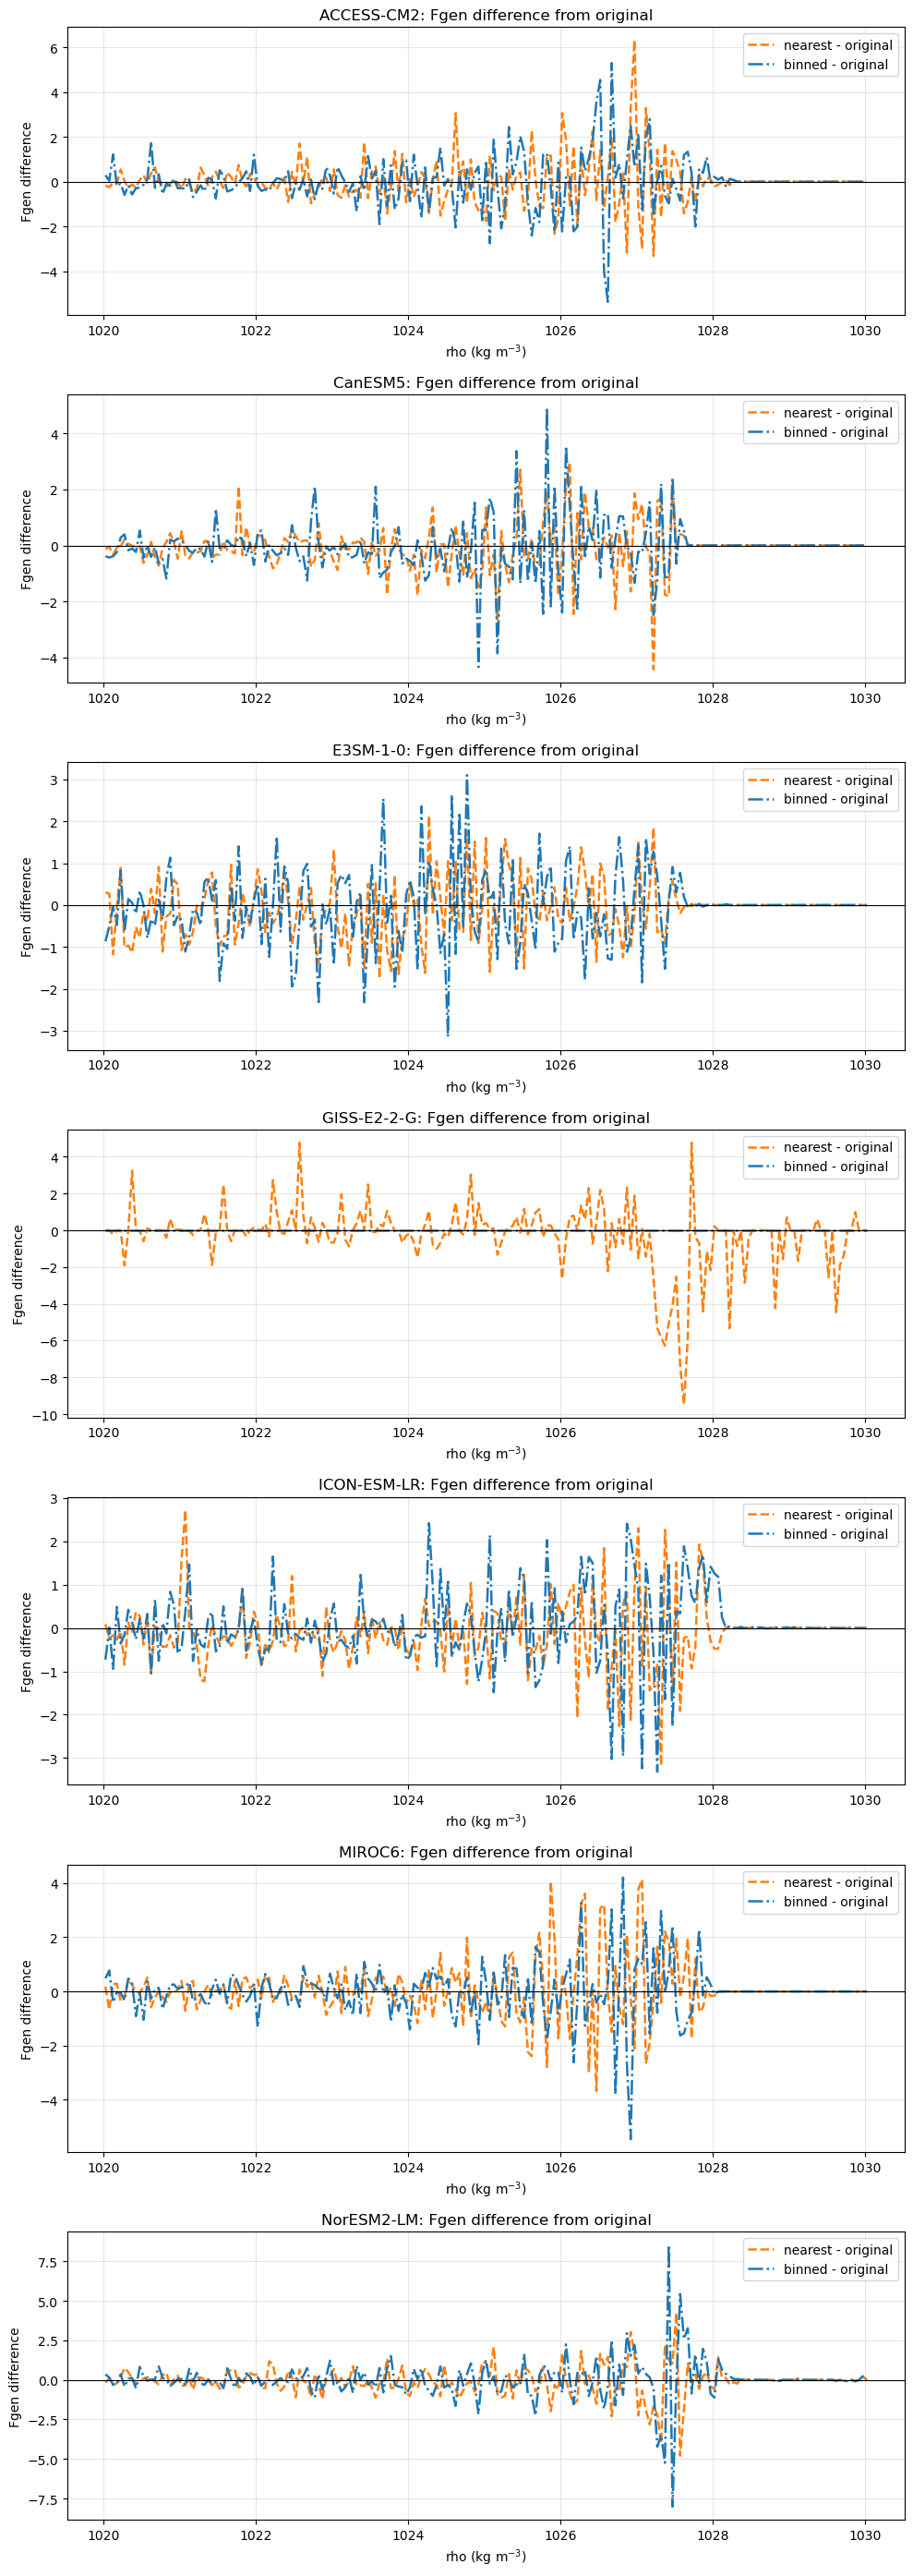

In [17]:
fig, axes = plt.subplots(len(common_models), 1, figsize=(10, 4 * len(common_models)), squeeze=False)
for axis, model in zip(axes.ravel(), common_models):
    original = results['original'][model].set_index('rho')['Fgen']
    for method in methods:
        if method == 'original':
            continue
        aligned = results[method][model].set_index('rho')['Fgen']
        difference = aligned - original
        difference = difference[difference.index >= RHO_PLOT_MIN]
        axis.plot(difference.index, difference.values, label=f'{method} - original', **METHOD_STYLES[method])
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set_title(f'{model}: Fgen difference from original')
    axis.set_xlabel('rho (kg m$^{-3}$)')
    axis.set_ylabel('Fgen difference')
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()


## Runtime and decision notes

Use runtime together with profile error metrics. A visually smooth profile is not automatically better if it changes the integrated signal substantially.


In [18]:
if not timings.empty:
    display(timings.pivot_table(index='model', columns='method', values='seconds', aggfunc='last'))

display(comparison.groupby('method').agg({
    'Fgen_RMSE': 'mean',
    'Fgen_max_abs_difference': 'mean',
    'Fgen_min_percent_difference': 'mean',
    'negative_Fgen_integral_percent_difference': 'mean',
    'AreaSum_total_percent_difference': 'mean',
}).sort_index())


method,binned,nearest,original
model,,,
ACCESS-CM2,0.439121,7.841238,0.446973
CanESM5,0.434377,7.228885,0.437947
E3SM-1-0,0.345702,5.694939,0.179786
FGOALS-f3-L,NaN,NaN,0.277720
GISS-E2-2-G,0.361184,2.595270,0.121280
ICON-ESM-LR,0.833898,19.265546,0.444890
MIROC6,0.402445,7.990203,0.236945
NorESM2-LM,0.509093,9.463613,0.261493


,Fgen_RMSE,Fgen_max_abs_difference,Fgen_min_percent_difference,negative_Fgen_integral_percent_difference,AreaSum_total_percent_difference
method,,,,,
binned,0.751876,4.389816,-4.382666,0.805957,-2.638744
nearest,0.889835,5.104273,-5.899214,5.599026,3.576800


## Interpretation checklist

- Prefer the method with acceptably small Fgen-profile and negative-integral differences across all tested grid families.
- Check component plots before attributing differences to heat or freshwater forcing.
- Expand the test window and model batch before changing the production Fgen workflow.
- Keep native-grid integration as the reference because regridding can move values between density classes.
